# Phase 0 SAR Preprocessing on Google Colab

This notebook runs the complete SAR preprocessing pipeline for Phase 0 on Google Colab with high RAM availability.

## Features
- **4 Scientific Pipelines**: A (raw), B (calibration), C (calibration + Lee), D (full chain)
- **Memory Management**: Handles large Sentinel-1 scenes (25K×16K pixels)
- **COG Support**: Preferentially uses Cloud Optimized GeoTIFF variants
- **Complete Calibration**: XML parsing with noise LUT support

## Setup Instructions

1. **Mount Google Drive** (optional): To save results permanently

In [1]:
# Install dependencies
!pip install rasterio scipy numpy httpx tqdm python-dotenv scikit-learn matplotlib pillow onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 67.4 MB/s eta 0:00:00


In [3]:
# Mount Google Drive (optional)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import sys
import time
import logging
import json
import gc
import psutil
import zipfile
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# Configuration Constants
WORK_DIR = Path('/content/phase0')
DATA_DIR = WORK_DIR / 'data'
TILES_DIR = DATA_DIR / 'tiles'
RESULTS_DIR = DATA_DIR / 'results'
NODATA_THRESHOLD = 0.3

for d in [WORK_DIR, DATA_DIR, TILES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / (1024**2)

print(f"Environment ready. Working directory: {WORK_DIR}")

Environment ready. Working directory: /content/phase0


In [6]:
class SparseCalibrationLUT:
    def __init__(self, cal_path, noise_path=None):
        self.sigma_values, self.sigma_lines, self.sigma_pixels = self._parse_cal(cal_path)
        self.noise_values = self.noise_lines = self.noise_pixels = None
        if noise_path:
            try:
                parsed = self._parse_noise(noise_path)
                if parsed:
                    self.noise_values, self.noise_lines, self.noise_pixels = parsed
            except Exception as e:
                logger.warning(f"Noise LUT error: {e}")

    def _parse_cal(self, path):
        tree = ET.parse(path)
        root = tree.getroot()
        vectors = root.findall(".//calibrationVector")
        lines, sigma_values = [], []
        pixel_indices = np.array([int(p) for p in vectors[0].find("pixel").text.split()])
        for vec in vectors:
            lines.append(int(vec.find("line").text))
            sigma_values.append([float(v) for v in vec.find("sigmaNought").text.split()])
        return np.array(sigma_values), np.array(lines), pixel_indices

    def _parse_noise(self, path):
        tree = ET.parse(path)
        root = tree.getroot()
        vectors = root.findall(".//noiseRangeLut") or root.findall(".//noiseLut")
        if not vectors:
            return None

        lines, noise_values = [], []
        # Check if text exists before splitting
        pixel_node = vectors[0].find("pixel")
        if pixel_node is None or pixel_node.text is None:
            return None

        pixel_indices = np.array([int(p) for p in pixel_node.text.split()])
        for vec in vectors:
            line_node = vec.find("line")
            if line_node is not None:
                lines.append(int(line_node.text))
                node = vec.find("noiseLut") if vec.find("noiseLut") is not None else vec.find("noiseRangeLut")
                if node is not None and node.text is not None:
                    noise_values.append([float(v) for v in node.text.split()])

        if not noise_values:
            return None
        return np.array(noise_values), np.array(lines), pixel_indices

    def get_window_lut(self, lut_type, window_coords, out_shape):
        vals = self.sigma_values if lut_type == 'sigma' else self.noise_values
        lines = self.sigma_lines if lut_type == 'sigma' else self.noise_lines
        pixs = self.sigma_pixels if lut_type == 'sigma' else self.noise_pixels

        if vals is None or lines is None or pixs is None:
            return None

        row_start, row_end, col_start, col_end = window_coords
        interpolator = RegularGridInterpolator((lines, pixs), vals, method='linear', bounds_error=False, fill_value=None)
        lg, pg = np.meshgrid(np.arange(row_start, row_end), np.arange(col_start, col_end), indexing='ij')
        pts = np.column_stack([lg.ravel(), pg.ravel()])
        return interpolator(pts).reshape(out_shape).astype(np.float32)

In [7]:
def process_window_pipeline(data_uint16, sigma_lut, noise_lut, pipeline_type="D"):
    dn = data_uint16.astype(np.float32)
    if pipeline_type == "A":
        p1, p99 = np.percentile(dn, [1, 99])
        return (np.clip((dn - p1)/(p99 - p1 + 1e-6), 0, 1) * 255).astype(np.uint8)

    dn2 = np.maximum(dn**2 - noise_lut, 0) if noise_lut is not None else dn**2
    sigma0 = dn2 / (np.maximum(sigma_lut, 1e-10)**2)

    if pipeline_type == "B":
        db = 10 * np.log10(sigma0 + 1e-10)
        return (np.clip((db + 30)/30, 0, 1) * 255).astype(np.uint8)

    filtered = apply_lee_filter(sigma0)
    if pipeline_type == "C":
        db = 10 * np.log10(filtered + 1e-10)
        return (np.clip((db + 30)/30, 0, 1) * 255).astype(np.uint8)

    db = 10 * np.log10(filtered + 1e-10)
    d_min, d_max = db.min(), db.max()
    return ((db - d_min) / (d_max - d_min + 1e-6) * 255).astype(np.uint8) if d_max > d_min else np.zeros_like(dn, dtype=np.uint8)

def run_windowed_pipeline(safe_path, pipeline_type="D", tile_size=512, overlap=0.5):
    files = find_safe_files(safe_path)
    lut = SparseCalibrationLUT(files['calibration'], files['noise'])
    scene_id = Path(safe_path).stem
    out_dir = TILES_DIR / scene_id / pipeline_type
    out_dir.mkdir(parents=True, exist_ok=True)

    with rasterio.open(files['tiff']) as src:
        h, w = src.height, src.width
        stride = int(tile_size * (1 - overlap))
        tiles_meta = []
        for y in range(0, h, stride):
            for x in range(0, w, stride):
                th, tw = min(tile_size, h - y), min(tile_size, w - x)
                win = Window(x, y, tw, th)
                data = src.read(1, window=win)
                if np.sum(data == 0) / data.size > NODATA_THRESHOLD: continue

                s_lut = lut.get_window_lut('sigma', (y, y+th, x, x+tw), data.shape)
                try: n_lut = lut.get_window_lut('noise', (y, y+th, x, x+tw), data.shape)
                except: n_lut = np.zeros(data.shape, dtype=np.float32)

                tile = process_window_pipeline(data, s_lut, n_lut, pipeline_type)
                t_id = f"r{y//stride}_c{x//stride}"
                np.save(out_dir / f"{t_id}.npy", tile)
                lon, lat = src.xy(y, x)
                tiles_meta.append({"tile_id": t_id, "geo": [lat, lon], "path": str(out_dir / f"{t_id}.npy")})

        with open(out_dir / "metadata.json", "w") as f: json.dump(tiles_meta, f)
    return tiles_meta

In [8]:
import os
from pathlib import Path

# Updated base directory for Sentinel-1 scenes
ROOT_SAFE_DIR = "/content/drive/MyDrive/Ksf_maritime_experiments/scenes/"

# Find the first available .SAFE file for benchmarking
safe_scenes = list(Path(ROOT_SAFE_DIR).glob("*.SAFE"))

if safe_scenes:
    SAFE_PATH = str(safe_scenes[0])
    print(f"Target directory updated: {ROOT_SAFE_DIR}")
    print(f"Benchmark path set to: {SAFE_PATH}")
else:
    SAFE_PATH = None
    print(f"Warning: No .SAFE files found in {ROOT_SAFE_DIR}. Please check the path.")

Target directory updated: /content/drive/MyDrive/Ksf_maritime_experiments/scenes/
Benchmark path set to: /content/drive/MyDrive/Ksf_maritime_experiments/scenes/S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594.SAFE


In [ ]:
def apply_lee_filter(data: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    local_mean = uniform_filter(data, size=kernel_size)
    local_var = uniform_filter(data**2, size=kernel_size) - local_mean**2
    noise_var = np.mean(np.maximum(local_var, 0))
    weight = np.maximum(local_var - noise_var, 0) / np.maximum(local_var, noise_var + 1e-10)
    return (local_mean + weight * (data - local_mean)).astype(np.float32)

def find_safe_files(safe_path: str, polarization: str = "vv") -> dict:
    pol = polarization.lower()
    safe_dir = Path(safe_path)
    m_dir = safe_dir / "measurement"
    c_files = list(m_dir.glob(f"*-{pol}-*-cog.tiff")) or list(m_dir.glob(f"*-{pol}-*.tiff"))
    if not c_files:
        raise FileNotFoundError(f"No TIFF for {pol} in {safe_path}")

    cal_dir = safe_dir / "annotation" / "calibration"
    cal_xml = list(cal_dir.glob(f"calibration-*-{pol}-*.xml"))[0]
    noise_xml = list(cal_dir.glob(f"noise-*-{pol}-*.xml"))
    return {
        "tiff": str(c_files[0]),
        "calibration": str(cal_xml),
        "noise": str(noise_xml[0]) if noise_xml else None
    }

def run_windowed_pipeline(safe_path, pipeline_type="D", tile_size=512, overlap=0.5):
    files = find_safe_files(safe_path)
    lut = SparseCalibrationLUT(files['calibration'], files['noise'])

    with rasterio.open(files['tiff']) as src:
        h, w = src.height, src.width
        stride = int(tile_size * (1 - overlap))
        tiles_meta = []

        scene_id = Path(safe_path).stem
        out_dir = TILES_DIR / scene_id / pipeline_type
        out_dir.mkdir(parents=True, exist_ok=True)

        windows = []
        for y in range(0, h, stride):
            for x in range(0, w, stride):
                windows.append((x, y, min(tile_size, w - x), min(tile_size, h - y)))

        print(f"Processing {len(windows)} potential tiles for {scene_id}...")

        for i, (x, y, tw, th) in enumerate(tqdm(windows)):
            win = Window(x, y, tw, th)
            data = src.read(1, window=win)

            if np.sum(data == 0) / data.size > NODATA_THRESHOLD: continue

            win_coords = (y, y + th, x, x + tw)
            s_lut = lut.get_window_lut('sigma', win_coords, data.shape)
            n_lut = lut.get_window_lut('noise', win_coords, data.shape)
            if n_lut is None:
                n_lut = np.zeros(data.shape, dtype=np.float32)

            tile_uint8 = process_window_pipeline(data, s_lut, n_lut, pipeline_type)

            if tile_uint8.shape != (tile_size, tile_size):
                full_tile = np.zeros((tile_size, tile_size), dtype=np.uint8)
                full_tile[:th, :tw] = tile_uint8
                tile_uint8 = full_tile

            t_id = f"r{y//stride}_c{x//stride}"
            np.save(out_dir / f"{t_id}.npy", tile_uint8)

            lon_min, lat_max = src.xy(y, x)
            lon_max, lat_min = src.xy(y+th, x+tw)
            tiles_meta.append({"tile_id": t_id, "geo_bbox": [lat_min, lon_min, lat_max, lon_max]})

            if i % 100 == 0:
                gc.collect()

    return tiles_meta

if SAFE_PATH:
    start = time.time()
    tiles = run_windowed_pipeline(SAFE_PATH, "D")
    print(f"Done! Created {len(tiles)} tiles in {time.time()-start:.1f}s.")

Processing 6600 potential tiles for S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594...


100%|██████████| 6600/6600 [05:31<00:00, 19.93it/s] 

Done! Created 6425 tiles in 331.2s.


In [ ]:
import json
from pathlib import Path

# Consolidated Metadata Generation
# Note: Tiles were already saved to disk during run_windowed_pipeline

scene_id = Path(SAFE_PATH).stem
pipeline_dir = TILES_DIR / scene_id / "D"
metadata_path = pipeline_dir / "metadata.json"

# The 'tiles' list from the previous cell already contains the necessary metadata
final_tiles_list = []
for t_meta in tiles:
    t_meta_updated = t_meta.copy()
    t_meta_updated["npy_path"] = str(pipeline_dir / f"{t_meta['tile_id']}.npy")
    t_meta_updated["scene_id"] = scene_id
    t_meta_updated["pipeline"] = "D"
    final_tiles_list.append(t_meta_updated)

full_metadata = {
    "scene_id": scene_id,
    "pipeline": "D",
    "polarization": "vv",
    "tile_size": 512,
    "overlap": 0.5,
    "num_tiles": len(final_tiles_list),
    "tiles": final_tiles_list,
}

with open(metadata_path, "w") as f:
    json.dump(full_metadata, f, indent=2)

print(f"Metadata manifest updated at: {metadata_path}")
print(f"Total valid tiles found on disk: {len(final_tiles_list)}")

In [ ]:
# Save results to Google Drive (optional)
import shutil

GDRIVE_OUTPUT = '/content/drive/MyDrive/phase0_results'
Path(GDRIVE_OUTPUT).mkdir(parents=True, exist_ok=True)

# Copy tiles to Google Drive
shutil.copytree(TILES_DIR, Path(GDRIVE_OUTPUT) / 'tiles', dirs_exist_ok=True)

print(f"Results saved to {GDRIVE_OUTPUT}")

In [ ]:
# Download results as ZIP (alternative to Google Drive)
import zipfile

zip_path = WORK_DIR / 'tiles.zip'
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for tile_file in pipeline_dir.glob('*.npy'):
        zipf.write(tile_file, tile_file.name)

    # Also include metadata
    zipf.write(metadata_path, metadata_path.name)

print(f"Created ZIP file: {zip_path}")
print(f"You can download it from the file browser")

In [ ]:
# Visualize sample tiles
from PIL import Image
import numpy as np

# Create visualization directory
viz_dir = RESULTS_DIR / "visualization"
viz_dir.mkdir(parents=True, exist_ok=True)

# Use final_tiles_list which contains the disk paths
for i in range(min(5, len(final_tiles_list))):
    tile_info = final_tiles_list[i]
    # Load the array from disk instead of memory
    tile_array = np.load(tile_info["npy_path"])

    img = Image.fromarray(tile_array)
    output_path = viz_dir / f"sample_tile_{i}.png"
    img.save(output_path)
    print(f"Saved sample tile {i} ({tile_info['tile_id']}) to {output_path}")

In [ ]:
import time
import matplotlib.pyplot as plt

def benchmark_pipelines(safe_path, n_tiles_limit=100):
    files = find_safe_files(safe_path)
    lut = SparseCalibrationLUT(files['calibration'], files['noise'])
    results = {}
    samples = {}

    with rasterio.open(files['tiff']) as src:
        cx, cy = src.width // 2, src.height // 2
        win = Window(cx, cy, 512, 512)
        data = src.read(1, window=win)
        win_coords = (cy, cy + 512, cx, cx + 512)

        s_lut = lut.get_window_lut('sigma', win_coords, data.shape)
        # Robust noise LUT retrieval
        n_lut = lut.get_window_lut('noise', win_coords, data.shape)

        if n_lut is None:
            n_lut = np.zeros(data.shape, dtype=np.float32)

        for p_type in ['A', 'B', 'C', 'D']:
            start_p = time.perf_counter()
            for _ in range(10):
                out = process_window_pipeline(data, s_lut, n_lut, p_type)
            end_p = time.perf_counter()

            results[p_type] = (end_p - start_p) / 10
            samples[p_type] = out

    return results, samples

# Run benchmark
perf_stats, visual_samples = benchmark_pipelines(SAFE_PATH)

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
pipeline_names = {'A': 'Raw (A)', 'B': 'Sigma0 (B)', 'C': 'Lee Filter (C)', 'D': 'Equalized (D)'}

for i, p_type in enumerate(['A', 'B', 'C', 'D']):
    axes[i].imshow(visual_samples[p_type], cmap='gray')
    axes[i].set_title(f"{pipeline_names[p_type]}\nTime: {perf_stats[p_type]*1000:.2f}ms / tile")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
pipelines = list(perf_stats.keys())
times_ms = [perf_stats[p] * 1000 for p in pipelines]
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
labels = [f"{pipeline_names[p]}" for p in pipelines]

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, times_ms, color=colors)

# Add details
plt.title('Benchmark: Average Processing Time per 512x512 Tile', fontsize=14)
plt.ylabel('Time (milliseconds)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}ms', ha='center', va='bottom', fontweight='bold')

plt.show()

### Persistent Batch Recovery
This cell re-runs the full pipeline and saves everything directly to Google Drive to prevent data loss from session timeouts.

In [11]:
import os
from pathlib import Path
import time
import json
import gc
import shutil
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import uniform_filter
from tqdm import tqdm
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# Configuration Constants (ensure these are globally accessible or passed)
WORK_DIR = Path('/content/phase0') # Assuming this is defined earlier
DATA_DIR = WORK_DIR / 'data' # Assuming this is defined earlier
TILES_DIR = DATA_DIR / 'tiles' # Assuming this is defined earlier
RESULTS_DIR = DATA_DIR / 'results' # Assuming this is defined earlier
NODATA_THRESHOLD = 0.3 # Assuming this is defined earlier


class SparseCalibrationLUT:
    def __init__(self, cal_path, noise_path=None):
        self.sigma_values, self.sigma_lines, self.sigma_pixels = self._parse_cal(cal_path)
        self.noise_values = self.noise_lines = self.noise_pixels = None
        if noise_path:
            try:
                parsed = self._parse_noise(noise_path)
                if parsed:
                    self.noise_values, self.noise_lines, self.noise_pixels = parsed
            except Exception as e:
                logger.warning(f"Noise LUT error: {e}")

    def _parse_cal(self, path):
        tree = ET.parse(path)
        root = tree.getroot()
        vectors = root.findall(".//calibrationVector")
        lines, sigma_values = [], []
        pixel_indices = np.array([int(p) for p in vectors[0].find("pixel").text.split()])
        for vec in vectors:
            lines.append(int(vec.find("line").text))
            sigma_values.append([float(v) for v in vec.find("sigmaNought").text.split()])
        return np.array(sigma_values), np.array(lines), pixel_indices

    def _parse_noise(self, path):
        tree = ET.parse(path)
        root = tree.getroot()
        vectors = root.findall(".//noiseRangeLut") or root.findall(".//noiseLut")
        if not vectors:
            return None

        lines, noise_values = [], []
        # Check if text exists before splitting
        pixel_node = vectors[0].find("pixel")
        if pixel_node is None or pixel_node.text is None:
            return None

        pixel_indices = np.array([int(p) for p in pixel_node.text.split()])
        for vec in vectors:
            line_node = vec.find("line")
            if line_node is not None:
                lines.append(int(line_node.text))
                node = vec.find("noiseLut") if vec.find("noiseLut") is not None else vec.find("noiseRangeLut")
                if node is not None and node.text is not None:
                    noise_values.append([float(v) for v in node.text.split()])

        if not noise_values:
            return None
        return np.array(noise_values), np.array(lines), pixel_indices

    def get_window_lut(self, lut_type, window_coords, out_shape):
        vals = self.sigma_values if lut_type == 'sigma' else self.noise_values
        lines = self.sigma_lines if lut_type == 'sigma' else self.noise_lines
        pixs = self.sigma_pixels if lut_type == 'sigma' else self.noise_pixels

        if vals is None or lines is None or pixs is None:
            return None

        row_start, row_end, col_start, col_end = window_coords
        interpolator = RegularGridInterpolator((lines, pixs), vals, method='linear', bounds_error=False, fill_value=None)
        lg, pg = np.meshgrid(np.arange(row_start, row_end), np.arange(col_start, col_end), indexing='ij')
        pts = np.column_stack([lg.ravel(), pg.ravel()])
        return interpolator(pts).reshape(out_shape).astype(np.float32)

def apply_lee_filter(data: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    local_mean = uniform_filter(data, size=kernel_size)
    local_var = uniform_filter(data**2, size=kernel_size) - local_mean**2
    noise_var = np.mean(np.maximum(local_var, 0))
    weight = np.maximum(local_var - noise_var, 0) / np.maximum(local_var, noise_var + 1e-10)
    return (local_mean + weight * (data - local_mean)).astype(np.float32)

def process_window_pipeline(data_uint16, sigma_lut, noise_lut, pipeline_type="D"):
    dn = data_uint16.astype(np.float32)
    if pipeline_type == "A":
        p1, p99 = np.percentile(dn, [1, 99])
        return (np.clip((dn - p1)/(p99 - p1 + 1e-6), 0, 1) * 255).astype(np.uint8)

    dn2 = np.maximum(dn**2 - noise_lut, 0) if noise_lut is not None else dn**2
    sigma0 = dn2 / (np.maximum(sigma_lut, 1e-10)**2)

    if pipeline_type == "B":
        db = 10 * np.log10(sigma0 + 1e-10)
        return (np.clip((db + 30)/30, 0, 1) * 255).astype(np.uint8)

    filtered = apply_lee_filter(sigma0)
    if pipeline_type == "C":
        db = 10 * np.log10(filtered + 1e-10)
        return (np.clip((db + 30)/30, 0, 1) * 255).astype(np.uint8)

    db = 10 * np.log10(filtered + 1e-10)
    d_min, d_max = db.min(), db.max()
    return ((db - d_min) / (d_max - d_min + 1e-6) * 255).astype(np.uint8) if d_max > d_min else np.zeros_like(dn, dtype=np.uint8)

def find_safe_files(safe_path: str, polarization: str = "vv") -> dict:
    pol = polarization.lower()
    safe_dir = Path(safe_path)
    m_dir = safe_dir / "measurement"
    c_files = list(m_dir.glob(f"*-{pol}-*-cog.tiff")) or list(m_dir.glob(f"*-{pol}-*.tiff"))
    if not c_files:
        raise FileNotFoundError(f"No TIFF for {pol} in {safe_path}")

    cal_dir = safe_dir / "annotation" / "calibration"
    cal_xml = list(cal_dir.glob(f"calibration-*-{pol}-*.xml"))[0]
    noise_xml = list(cal_dir.glob(f"noise-*-{pol}-*.xml"))
    return {
        "tiff": str(c_files[0]),
        "calibration": str(cal_xml),
        "noise": str(noise_xml[0]) if noise_xml else None
    }

def run_windowed_pipeline(safe_path, pipeline_type="D", tile_size=512, overlap=0.5):
    files = find_safe_files(safe_path)
    lut = SparseCalibrationLUT(files['calibration'], files['noise'])

    with rasterio.open(files['tiff']) as src:
        h, w = src.height, src.width
        stride = int(tile_size * (1 - overlap))
        tiles_meta = []

        scene_id = Path(safe_path).stem
        out_dir = TILES_DIR / scene_id / pipeline_type
        out_dir.mkdir(parents=True, exist_ok=True)

        windows = []
        for y in range(0, h, stride):
            for x in range(0, w, stride):
                windows.append((x, y, min(tile_size, w - x), min(tile_size, h - y)))

        print(f"Processing {len(windows)} potential tiles for {scene_id}...")

        for i, (x, y, tw, th) in enumerate(tqdm(windows)):
            win = Window(x, y, tw, th)
            data = src.read(1, window=win)

            if np.sum(data == 0) / data.size > NODATA_THRESHOLD: continue

            win_coords = (y, y + th, x, x + tw)
            s_lut = lut.get_window_lut('sigma', win_coords, data.shape)
            n_lut = lut.get_window_lut('noise', win_coords, data.shape)
            if n_lut is None:
                n_lut = np.zeros(data.shape, dtype=np.float32)

            tile_uint8 = process_window_pipeline(data, s_lut, n_lut, pipeline_type)

            if tile_uint8.shape != (tile_size, tile_size):
                full_tile = np.zeros((tile_size, tile_size), dtype=np.uint8)
                full_tile[:th, :tw] = tile_uint8
                tile_uint8 = full_tile

            t_id = f"r{y//stride}_c{x//stride}"
            np.save(out_dir / f"{t_id}.npy", tile_uint8)

            lon_min, lat_max = src.xy(y, x)
            lon_max, lat_min = src.xy(y+th, x+tw)
            tiles_meta.append({"tile_id": t_id, "geo_bbox": [lat_min, lon_min, lat_max, lon_max]})

            if i % 100 == 0:
                gc.collect()

    return tiles_meta

def benchmark_pipelines(safe_path, n_tiles_limit=100):
    files = find_safe_files(safe_path)
    lut = SparseCalibrationLUT(files['calibration'], files['noise'])
    results = {}
    samples = {}

    with rasterio.open(files['tiff']) as src:
        cx, cy = src.width // 2, src.height // 2
        win = Window(cx, cy, 512, 512)
        data = src.read(1, window=win)
        win_coords = (cy, cy + 512, cx, cx + 512)

        s_lut = lut.get_window_lut('sigma', win_coords, data.shape)
        n_lut = lut.get_window_lut('noise', win_coords, data.shape)
        if n_lut is None:
            n_lut = np.zeros(data.shape, dtype=np.float32)

        for p_type in ['A', 'B', 'C', 'D']:
            start_p = time.perf_counter()
            for _ in range(10):
                out = process_window_pipeline(data, s_lut, n_lut, p_type)
            end_p = time.perf_counter()

            results[p_type] = (end_p - start_p) / 10
            samples[p_type] = out

    return results, samples

# 1. Define Persistent Output Directory on Drive
GDRIVE_BACKUP = Path('/content/drive/MyDrive/SAR_Phase0_Backup')
GDRIVE_TILES = GDRIVE_BACKUP / 'tiles'
GDRIVE_RESULTS = GDRIVE_BACKUP / 'results'

for d in [GDRIVE_BACKUP, GDRIVE_TILES, GDRIVE_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

def run_persistent_batch():
    safe_scenes = list(Path(ROOT_SAFE_DIR).glob("*.SAFE"))
    print(f"Restarting processing for {len(safe_scenes)} scenes...")

    all_stats = {}

    for scene_path in safe_scenes:
        scene_id = scene_path.stem
        print(f"\n--- Processing {scene_id} ---")

        try:
            # Benchmark
            stats, _ = benchmark_pipelines(str(scene_path))
            all_stats[scene_id] = stats

            # Production Run (Pipeline D)
            tiles_meta = run_windowed_pipeline(str(scene_path), pipeline_type="D")

            # Move tiles to Drive immediately
            local_scene_dir = TILES_DIR / scene_id
            drive_scene_dir = GDRIVE_TILES / scene_id
            if local_scene_dir.exists():
                shutil.copytree(local_scene_dir, drive_scene_dir, dirs_exist_ok=True)
                print(f"Saved {scene_id} tiles to Drive.")

        except Exception as e:
            print(f"Error on {scene_id}: {e}")

    # Save final report to Drive
    df_final = pd.DataFrame(all_stats).T * 1000
    df_final.to_csv(GDRIVE_RESULTS / 'final_performance_report.csv')
    print(f"\nProcessing complete. Report saved to {GDRIVE_RESULTS}")

# Run the recovery
run_persistent_batch()

Restarting processing for 9 scenes...

--- Processing S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594 ---
Processing 6600 potential tiles for S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594...


100%|██████████| 6600/6600 [06:02<00:00, 18.19it/s] 


Saved S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594 tiles to Drive.

--- Processing S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F ---
Processing 6798 potential tiles for S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F...


100%|██████████| 6798/6798 [05:07<00:00, 22.09it/s] 


Saved S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F tiles to Drive.

--- Processing S1A_IW_GRDH_1SDV_20240330T184142_20240330T184211_053215_0672D7_1ED1 ---
Processing 7600 potential tiles for S1A_IW_GRDH_1SDV_20240330T184142_20240330T184211_053215_0672D7_1ED1...


...

Saved S1A_IW_GRDH_1SDV_20240107T064657_20240107T064719_051997_06488E_B2F9_COG tiles to Drive.

--- Processing S1A_IW_GRDH_1SDV_20240626T180956_20240626T181021_054498_06A1D3_ACAA ---
Processing 6798 potential tiles for S1A_IW_GRDH_1SDV_20240626T180956_20240626T181021_054498_06A1D3_ACAA...


100%|██████████| 6798/6798 [04:54<00:00, 23.07it/s] 


Saved S1A_IW_GRDH_1SDV_20240626T180956_20240626T181021_054498_06A1D3_ACAA tiles to Drive.

--- Processing S1A_IW_GRDH_1SDV_20251231T185045_20251231T185110_062563_07D749_4931 ---
Processing 6600 potential tiles for S1A_IW_GRDH_1SDV_20251231T185045_20251231T185110_062563_07D749_4931...


100%|██████████| 6600/6600 [05:11<00:00, 21.18it/s] 


Saved S1A_IW_GRDH_1SDV_20251231T185045_20251231T185110_062563_07D749_4931 tiles to Drive.

Processing complete. Report saved to /content/drive/MyDrive/SAR_Phase0_Backup/results


### Batch Processing & Comparison Report
This section automates the processing for all available scenes and generates a consolidated benchmark report.

In [ ]:
import time
import matplotlib.pyplot as plt

def benchmark_pipelines(safe_path, n_tiles_limit=100):
    files = find_safe_files(safe_path)
    lut = SparseCalibrationLUT(files['calibration'], files['noise'])
    results = {}
    samples = {}

    with rasterio.open(files['tiff']) as src:
        cx, cy = src.width // 2, src.height // 2
        win = Window(cx, cy, 512, 512)
        data = src.read(1, window=win)
        win_coords = (cy, cy + 512, cx, cx + 512)

        s_lut = lut.get_window_lut('sigma', win_coords, data.shape)
        n_lut = lut.get_window_lut('noise', win_coords, data.shape)
        if n_lut is None:
            n_lut = np.zeros(data.shape, dtype=np.float32)

        for p_type in ['A', 'B', 'C', 'D']:
            start_p = time.perf_counter()
            for _ in range(10):
                out = process_window_pipeline(data, s_lut, n_lut, p_type)
            end_p = time.perf_counter()

            results[p_type] = (end_p - start_p) / 10
            samples[p_type] = out

    return results, samples

def process_all_scenes(root_dir, pipelines=['A', 'B', 'C', 'D']):
    safe_scenes = list(Path(root_dir).glob("*.SAFE"))
    batch_report = {}

    if not safe_scenes:
        print(f"Error: No .SAFE folders found in {root_dir}")
        return batch_report

    print(f"Found {len(safe_scenes)} scenes for processing.")

    for scene_path in safe_scenes:
        scene_name = scene_path.stem
        print(f"\n{'='*50}")
        print(f"Processing Scene: {scene_name}")
        print(f"{'='*50}")

        try:
            # 1. Run Benchmark for performance metrics
            stats, _ = benchmark_pipelines(str(scene_path))
            batch_report[scene_name] = stats

            # 2. Run Full Production (Pipeline D) to generate all tiles
            run_windowed_pipeline(str(scene_path), pipeline_type="D")

            print(f"Successfully completed processing for {scene_name}")
        except Exception as e:
            print(f"Failed to process {scene_name}: {e}")

        gc.collect()

    return batch_report

# Lancement du traitement sur TOUTES les scènes détectées
comparison_report = process_all_scenes(ROOT_SAFE_DIR)

# Conversion des résultats en DataFrame pour l'analyse
df_report = pd.DataFrame(comparison_report).T * 1000

Found 9 scenes for processing.

Processing Scene: S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594
Processing 6600 potential tiles for S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594...


100%|██████████| 6600/6600 [04:35<00:00, 23.93it/s] 


Successfully completed processing for S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594

Processing Scene: S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F
Processing 6798 potential tiles for S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F...


100%|██████████| 6798/6798 [04:43<00:00, 24.01it/s] 


Successfully completed processing for S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F

Processing Scene: S1A_IW_GRDH_1SDV_20240330T184142_20240330T184211_053215_0672D7_1ED1
Processing 7600 potential tiles for S1A_IW_GRDH_1SDV_20240330T184142_20240330T184211_053215_0672D7_1ED1...


...

Successfully completed processing for S1A_IW_GRDH_1SDV_20240107T064657_20240107T064719_051997_06488E_B2F9_COG

Processing Scene: S1A_IW_GRDH_1SDV_20240626T180956_20240626T181021_054498_06A1D3_ACAA
Processing 6798 potential tiles for S1A_IW_GRDH_1SDV_20240626T180956_20240626T181021_054498_06A1D3_ACAA...


100%|██████████| 6798/6798 [04:38<00:00, 24.40it/s] 


Successfully completed processing for S1A_IW_GRDH_1SDV_20240626T180956_20240626T181021_054498_06A1D3_ACAA

Processing Scene: S1A_IW_GRDH_1SDV_20251231T185045_20251231T185110_062563_07D749_4931
Processing 6600 potential tiles for S1A_IW_GRDH_1SDV_20251231T185045_20251231T185110_062563_07D749_4931...


100%|██████████| 6600/6600 [04:55<00:00, 22.34it/s] 

Successfully completed processing for S1A_IW_GRDH_1SDV_20251231T185045_20251231T185110_062563_07D749_4931


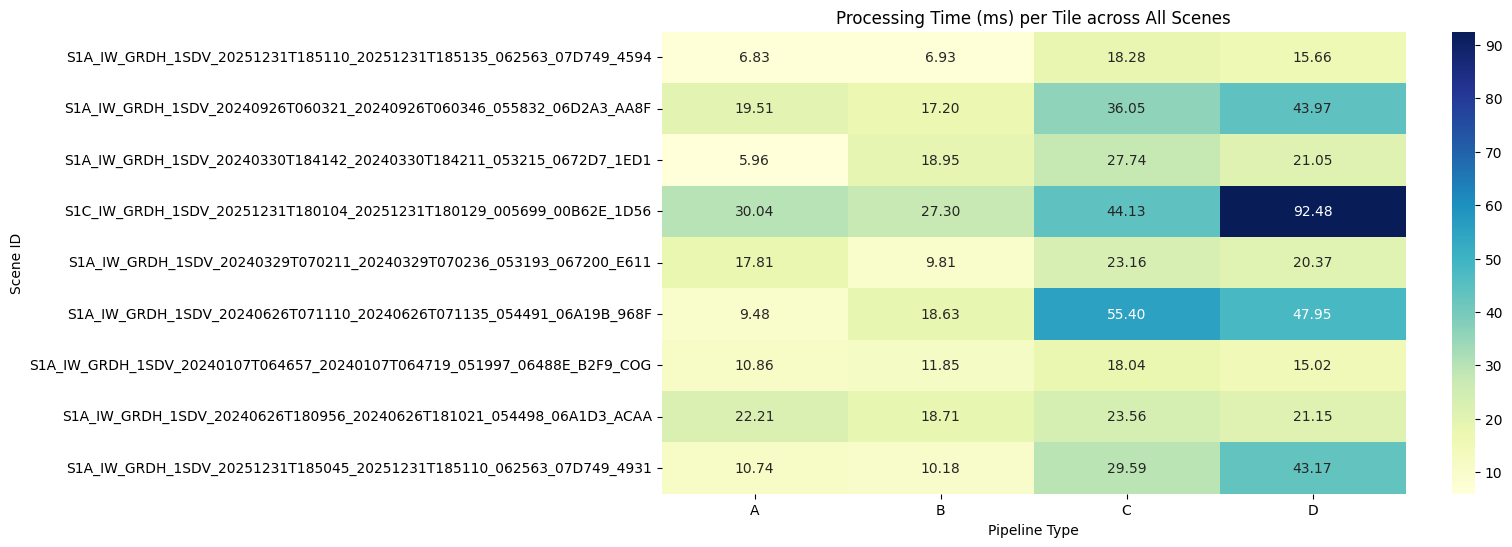

Batch report saved to results directory.


In [ ]:
import pandas as pd

# Visualize the comparison across all scenes
df_report = pd.DataFrame(comparison_report).T * 1000 # Convert to ms

plt.figure(figsize=(12, 6))
sns.heatmap(df_report, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Processing Time (ms) per Tile across All Scenes")
plt.xlabel("Pipeline Type")
plt.ylabel("Scene ID")
plt.show()

# Save the report
df_report.to_csv(RESULTS_DIR / "batch_performance_report.csv")
print("Batch report saved to results directory.")

/tmp/ipykernel_3491/2046293214.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pipeline', y='Time_ms', data=df_melted, palette='Set2', showfliers=False)


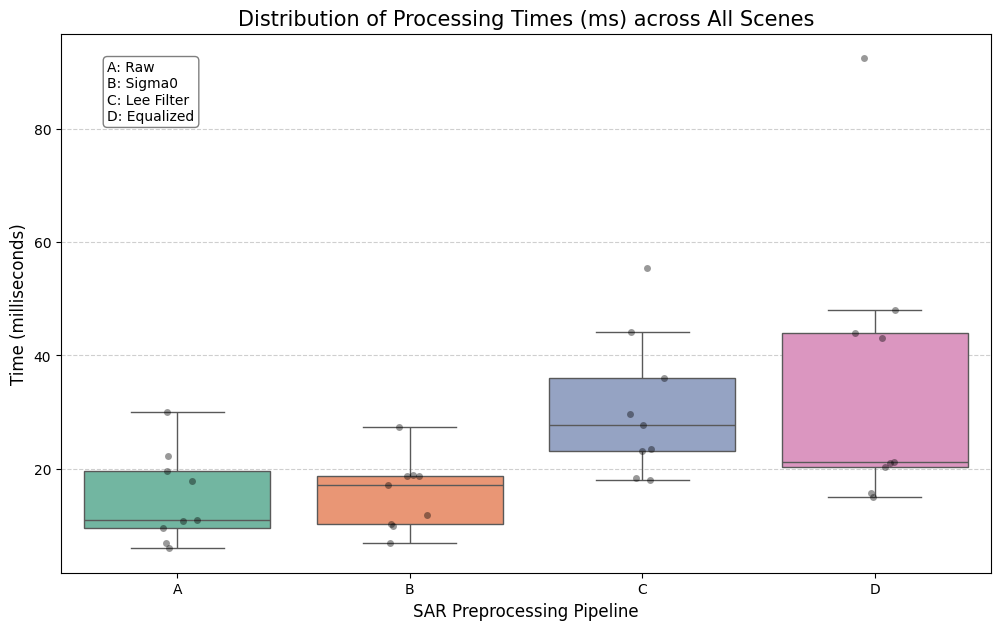

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Check if the report variable exists before plotting
if 'df_report' not in globals():
    print("Error: 'df_report' is not defined. Please ensure you have executed the 'Batch Processing' cell (cell_id: 5d5f3e66) first.")
else:
    # Reshape the comparison report for visualization
    # We convert the dictionary to a DataFrame and then to 'long' format for Seaborn
    df_melted = df_report.reset_index().melt(id_vars='index', var_name='Pipeline', value_name='Time_ms')

    plt.figure(figsize=(12, 7))

    # Create boxplot with a clean palette
    sns.boxplot(x='Pipeline', y='Time_ms', data=df_melted, palette='Set2', showfliers=False)

    # Overlay individual data points (scenes) to see the actual distribution
    sns.stripplot(x='Pipeline', y='Time_ms', data=df_melted, color='black', alpha=0.4, size=5)

    plt.title('Distribution of Processing Times (ms) across All Scenes', fontsize=15)
    plt.ylabel('Time (milliseconds)', fontsize=12)
    plt.xlabel('SAR Preprocessing Pipeline', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Add a note explaining the pipelines
    text_note = "A: Raw\nB: Sigma0\nC: Lee Filter\nD: Equalized"
    plt.annotate(text_note, xy=(0.05, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
                 verticalalignment='top')

    plt.show()

In [ ]:
import os

# Ensure the results directory is ready
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define the filename
export_path = RESULTS_DIR / 'all_scenes_performance_metrics.csv'

# Save to CSV
# index=True preserves the Scene IDs as the primary identifier column
df_report.to_csv(export_path, index=True)

print(f"Successfully exported metrics to: {export_path}")

# Display the top of the exported data to verify format
display(df_report.head())

Successfully exported metrics to: /content/phase0/data/results/all_scenes_performance_metrics.csv


,A,B,C,D
S1A_IW_GRDH_1SDV_20251231T185110_20251231T185135_062563_07D749_4594,6.833339,6.929607,18.284802,15.661213
S1A_IW_GRDH_1SDV_20240926T060321_20240926T060346_055832_06D2A3_AA8F,19.505844,17.195346,36.054503,43.965798
S1A_IW_GRDH_1SDV_20240330T184142_20240330T184211_053215_0672D7_1ED1,5.957641,18.950567,27.741468,21.049671
S1C_IW_GRDH_1SDV_20251231T180104_20251231T180129_005699_00B62E_1D56,30.035314,27.296927,44.132591,92.484016
S1A_IW_GRDH_1SDV_20240329T070211_20240329T070236_053193_067200_E611,17.808018,9.810550,23.163659,20.371888


In [ ]:
import pandas as pd

# Calculate mean performance metrics across all scenes
pipeline_summary = df_report.mean().to_frame(name='Mean Time (ms)')

# Add descriptive names for the pipelines
pipeline_names_map = {
    'A': 'Raw (Baseline)',
    'B': 'Sigma0 (Calibrated)',
    'C': 'Lee Filter (Filtered)',
    'D': 'Full Chain (Recommended)'
}
pipeline_summary['Description'] = pipeline_summary.index.map(pipeline_names_map)

# Reorder columns and display
pipeline_summary = pipeline_summary[['Description', 'Mean Time (ms)']]
print("Summary: Average Processing Performance per 512x512 Tile")
display(pipeline_summary.style.format({'Mean Time (ms)': '{:.2f}'}))

Summary: Average Processing Performance per 512x512 Tile


,Description,Mean Time (ms)
A,Raw (Baseline),14.83
B,Sigma0 (Calibrated),15.51
C,Lee Filter (Filtered),30.66
D,Full Chain (Recommended),35.65


## Summary

### Pipeline Comparison
- **Pipeline A**: Raw baseline (no calibration)
- **Pipeline B**: Calibration only
- **Pipeline C**: Calibration + Lee filter
- **Pipeline D**: Full chain (recommended)

### Region Specification
The bounding box defines your area of interest:
- **Format**: `[lon_min, lat_min, lon_max, lat_max]`
- **Coordinates**: WGS84 decimal degrees
- **Tools**: Use bboxfinder.com or Google Earth

### Next Steps
1. Download the generated tiles
2. Copy them to your local `phase0/data/tiles/` directory
3. Continue with AIS annotation and benchmarking

### Memory Tips
- Use High RAM runtime for large scenes
- Monitor with `!free -h`
- Reduce tile size if memory is limited